In [ ]:
# code that tests the wedge filtering generally done for the 21cm signal to act like observations

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
import warnings
from powerbox.tools import get_power
import tools21cm
from astropy.cosmology import Planck18



# ===========

In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("Loading 21cmFAST data...")

# Simulation parameters
BOX_SIZE_MPC = 300.0  # Mpc/h
LITTLEH = 0.7

sim_ids = list(range(12701, 12731))  # 30 simulations
n_sims = len(sim_ids)

den = np.load("data_21cmfast/density/12701_density_LC.npy")
xhi = np.load("data_21cmfast/xHI/12701_xHI_LC.npy")
vz = np.load("data_21cmfast/velocity/12701_velocity_z_LC.npy")
tb = np.load("data_21cmfast/Tb/12701_Tb_LC.npy")
redshifts = np.load("data_21cmfast/lightcone_redshifts.npy")

nx, ny, nz = den.shape
print(f"Shape (nx, ny, nz): {den.shape}")
print(f"Redshifts: {len(redshifts)} values, range [{redshifts.min():.3f}, {redshifts.max():.3f}]")

# Calculate cell size (pixel size in Mpc/h)
cell_size = BOX_SIZE_MPC / nx  # Transverse pixel size
print(f"\nBox size: {BOX_SIZE_MPC} Mpc/h")
print(f"Cell size (pixel size): {cell_size:.3f} Mpc/h")

Loading 21cmFAST data...
Shape (nx, ny, nz): (200, 200, 2553)
Redshifts: 2553 values, range [5.000, 35.040]

Box size: 300.0 Mpc/h
Cell size (pixel size): 1.500 Mpc/h


In [3]:
# Create output directory
import os
os.makedirs('plots', exist_ok=True)
print("Output directory ready: plots/")

Output directory ready: plots/


In [4]:

# Choose z ~ 8.0 for analysis (middle of reionization)
target_z = 8.0
z_idx = np.argmin(np.abs(redshifts - target_z))
actual_z = redshifts[z_idx]

print(f"\nTarget redshift: z = {target_z}")
print(f"Actual redshift: z = {actual_z:.3f} (index {z_idx})")

# Extract a chunk around this redshift for analysis
chunk_size = 2400 # slices
z_start = max(0, z_idx - chunk_size // 2)
z_end = min(nz, z_start + chunk_size)
z_start = z_end - chunk_size  # Ensure we get exactly chunk_size slices

den_chunk = den[:, :, z_start:z_end].copy()
xhi_chunk = xhi[:, :, z_start:z_end].copy()
vz_chunk = vz[:, :, z_start:z_end].copy()
tb_chunk = tb[:, :, z_start:z_end].copy()
redshifts_chunk = redshifts[z_start:z_end].copy()

print(f"Chunk shape: {den_chunk.shape}")
print(f"Chunk redshift range: [{redshifts_chunk.min():.3f}, {redshifts_chunk.max():.3f}]")
print(f"Mean Tb in chunk: {tb_chunk.mean():.4f} mK")



Target redshift: z = 8.0
Actual redshift: z = 7.998 (index 790)
Chunk shape: (200, 200, 2400)
Chunk redshift range: [5.000, 29.497]
Mean Tb in chunk: -17.4292 mK


In [5]:

print("\nApplying wedge removal filter...")

# Apply wedge filter to density and velocity
den_filtered = tools21cm.foreground_model.rolling_wedge_removal_lightcone(
    den_chunk, redshifts_chunk, 
    cell_size=None, chunk_length=None, OMm=None, buffer_threshold=1e-10
)

vz_filtered = tools21cm.foreground_model.rolling_wedge_removal_lightcone(
    vz_chunk, redshifts_chunk,
    cell_size=None, chunk_length=None, OMm=None, buffer_threshold=1e-10
)

tb_filtered = tools21cm.foreground_model.rolling_wedge_removal_lightcone(
    tb_chunk, redshifts_chunk,
    cell_size=None, chunk_length=None, OMm=None, buffer_threshold=1e-10
)

print("Filtering complete!")
print(f"Density - Original std: {den_chunk.std():.4f}, Filtered std: {den_filtered.std():.4f}")
print(f"Velocity - Original std: {vz_chunk.std():.2f}, Filtered std: {vz_filtered.std():.2f}")
print(f"21cm - Original std: {tb_chunk.std():.4f}, Filtered std: {tb_filtered.std():.4f}")



Applying wedge removal filter...
Filtering complete!
Density - Original std: 0.3020, Filtered std: 0.0339
Velocity - Original std: 0.00, Filtered std: 0.00
21cm - Original std: 30.2131, Filtered std: 0.7278


In [6]:

print("\nComputing 3D Fourier transforms...")

# Unfiltered fields
den_fft_unfiltered = fft.fftn(den_chunk)
vz_fft_unfiltered = fft.fftn(vz_chunk)
tb_fft_unfiltered = fft.fftn(tb_chunk)

# Filtered fields
den_fft_filtered = fft.fftn(den_filtered)
vz_fft_filtered = fft.fftn(vz_filtered)
tb_fft_filtered = fft.fftn(tb_filtered)

# Compute power (|FFT|^2)
den_power_unfiltered = np.abs(den_fft_unfiltered)**2
den_power_filtered = np.abs(den_fft_filtered)**2
vz_power_unfiltered = np.abs(vz_fft_unfiltered)**2
vz_power_filtered = np.abs(vz_fft_filtered)**2
t21_power_unfiltered = np.abs(tb_fft_unfiltered)**2
t21_power_filtered = np.abs(tb_fft_filtered)**2

print("FFT computation complete!")

# ============================================================================
# CELL 6: Compute k-space Coordinates
# ============================================================================

# k_perp = sqrt(kx^2 + ky^2), k_parallel = kz
nx_chunk, ny_chunk, nz_chunk = den_chunk.shape

# Frequency arrays (in units of 1/pixel)
kx_freq = fft.fftfreq(nx_chunk)
ky_freq = fft.fftfreq(ny_chunk)
kz_freq = fft.fftfreq(nz_chunk)

# Create 3D grids
KX, KY, KZ = np.meshgrid(kx_freq, ky_freq, kz_freq, indexing='ij')

# Compute k_perp and k_parallel
k_perp = np.sqrt(KX**2 + KY**2)
k_parallel = np.abs(KZ)

print(f"\nk_perp range: [{k_perp.min():.4f}, {k_perp.max():.4f}]")
print(f"k_parallel range: [{k_parallel.min():.4f}, {k_parallel.max():.4f}]")

# ============================================================================
# CELL 7: Compute Filter Transfer Function
# ============================================================================

# The filter is the ratio of filtered to unfiltered power
# Avoid division by zero
eps = 1e-20

# Compute filter for each field
filter_den = np.sqrt(den_power_filtered / (den_power_unfiltered + eps))
filter_vz = np.sqrt(vz_power_filtered / (vz_power_unfiltered + eps))
filter_t21 = np.sqrt(t21_power_filtered / (t21_power_unfiltered + eps))

# Clip to [0, 1] range
filter_den = np.clip(filter_den, 0, 1)
filter_vz = np.clip(filter_vz, 0, 1)
filter_t21 = np.clip(filter_t21, 0, 1)

print("\nFilter transfer functions computed!")
print(f"Density filter - mean: {filter_den.mean():.4f}, min: {filter_den.min():.4f}")
print(f"Velocity filter - mean: {filter_vz.mean():.4f}, min: {filter_vz.min():.4f}")
print(f"21cm filter - mean: {filter_t21.mean():.4f}, min: {filter_t21.min():.4f}")


Computing 3D Fourier transforms...
FFT computation complete!

k_perp range: [0.0000, 0.7071]
k_parallel range: [0.0000, 0.5000]

Filter transfer functions computed!
Density filter - mean: 0.0241, min: 0.0000
Velocity filter - mean: 0.0000, min: 0.0000
21cm filter - mean: 0.0118, min: 0.0000


In [7]:

def bin_filter_2d(k_perp, k_parallel, filter_values, n_bins=50):
    """
    Bin filter values in (k_perp, k_parallel) space.
    """
    # Define bin edges
    k_perp_edges = np.linspace(0, k_perp.max(), n_bins + 1)
    k_par_edges = np.linspace(0, k_parallel.max(), n_bins + 1)
    
    # Initialize arrays
    filter_binned = np.zeros((n_bins, n_bins))
    counts = np.zeros((n_bins, n_bins))
    
    # Flatten arrays
    k_perp_flat = k_perp.ravel()
    k_par_flat = k_parallel.ravel()
    filter_flat = filter_values.ravel()
    
    # Bin the data
    for i in range(len(k_perp_flat)):
        # Find bin indices
        i_perp = np.searchsorted(k_perp_edges, k_perp_flat[i]) - 1
        i_par = np.searchsorted(k_par_edges, k_par_flat[i]) - 1
        
        # Check bounds
        if 0 <= i_perp < n_bins and 0 <= i_par < n_bins:
            filter_binned[i_perp, i_par] += filter_flat[i]
            counts[i_perp, i_par] += 1
    
    # Average
    mask = counts > 0
    filter_binned[mask] /= counts[mask]
    filter_binned[~mask] = np.nan
    
    # Bin centers
    k_perp_centers = 0.5 * (k_perp_edges[:-1] + k_perp_edges[1:])
    k_par_centers = 0.5 * (k_par_edges[:-1] + k_par_edges[1:])
    
    return k_perp_centers, k_par_centers, filter_binned

print("\nBinning filters in k-space...")
n_bins = 60

k_perp_bins, k_par_bins, filter_den_2d = bin_filter_2d(k_perp, k_parallel, filter_den, n_bins)
k_perp_bins, k_par_bins, filter_vz_2d = bin_filter_2d(k_perp, k_parallel, filter_vz, n_bins)
k_perp_bins, k_par_bins, filter_t21_2d = bin_filter_2d(k_perp, k_parallel, filter_t21, n_bins)

print("Binning complete!")


Binning filters in k-space...
Binning complete!



Creating filter visualization...


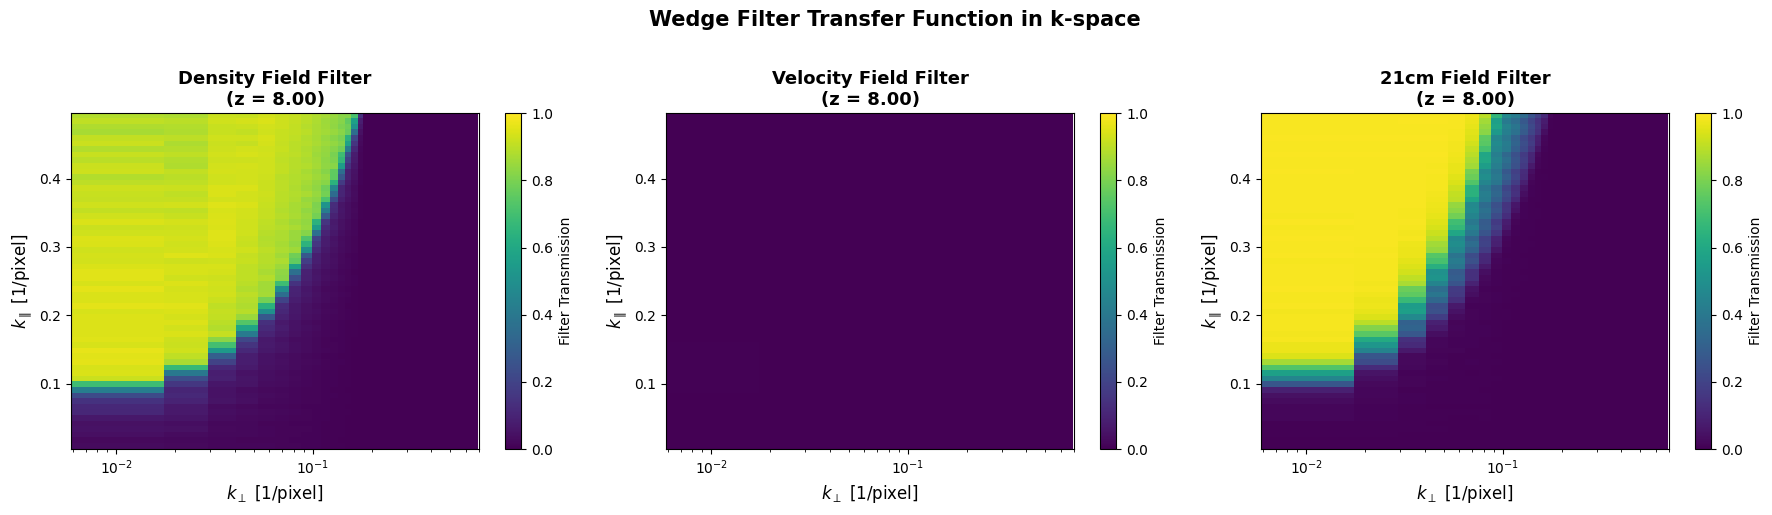

Filter visualization saved!


In [8]:

print("\nCreating filter visualization...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot parameters
vmin, vmax = 0, 1
cmap = 'viridis'

# Plot 1: Density field filter
ax = axes[0]
im = ax.imshow(filter_den_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_xscale('log')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title(f'Density Field Filter\n(z = {actual_z:.2f})', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Filter Transmission')

# Plot 2: Velocity field filter
ax = axes[1]
im = ax.imshow(filter_vz_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_xscale('log')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title(f'Velocity Field Filter\n(z = {actual_z:.2f})', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Filter Transmission')

# Plot 3: 21cm field filter
ax = axes[2]
im = ax.imshow(filter_t21_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap=cmap, vmin=vmin, vmax=vmax)
ax.set_xscale('log')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title(f'21cm Field Filter\n(z = {actual_z:.2f})', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Filter Transmission')

plt.suptitle('Wedge Filter Transfer Function in k-space', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/wedge_filter_kspace.png', dpi=300, bbox_inches='tight')
plt.show()

print("Filter visualization saved!")


In [9]:

def find_wedge_boundary(k_perp_bins, k_par_bins, filter_2d, threshold=0.5):
    """
    Find the wedge boundary where filter drops below threshold.
    """
    wedge_boundary = []
    
    for i, kp in enumerate(k_perp_bins):
        if kp == 0:
            continue
        # Find first k_parallel where filter > threshold
        filter_slice = filter_2d[i, :]
        valid = np.where(filter_slice > threshold)[0]
        if len(valid) > 0:
            k_par_boundary = k_par_bins[valid[0]]
            wedge_boundary.append((kp, k_par_boundary))
    
    if len(wedge_boundary) > 0:
        wedge_boundary = np.array(wedge_boundary)
        return wedge_boundary[:, 0], wedge_boundary[:, 1]
    else:
        return np.array([]), np.array([])

threshold = 0.5
kp_wedge_den, kpar_wedge_den = find_wedge_boundary(k_perp_bins, k_par_bins, filter_den_2d, threshold)
kp_wedge_vz, kpar_wedge_vz = find_wedge_boundary(k_perp_bins, k_par_bins, filter_vz_2d, threshold)
kp_wedge_t21, kpar_wedge_t21 = find_wedge_boundary(k_perp_bins, k_par_bins, filter_t21_2d, threshold)

print(f"\nWedge boundaries identified (threshold = {threshold})")



Wedge boundaries identified (threshold = 0.5)


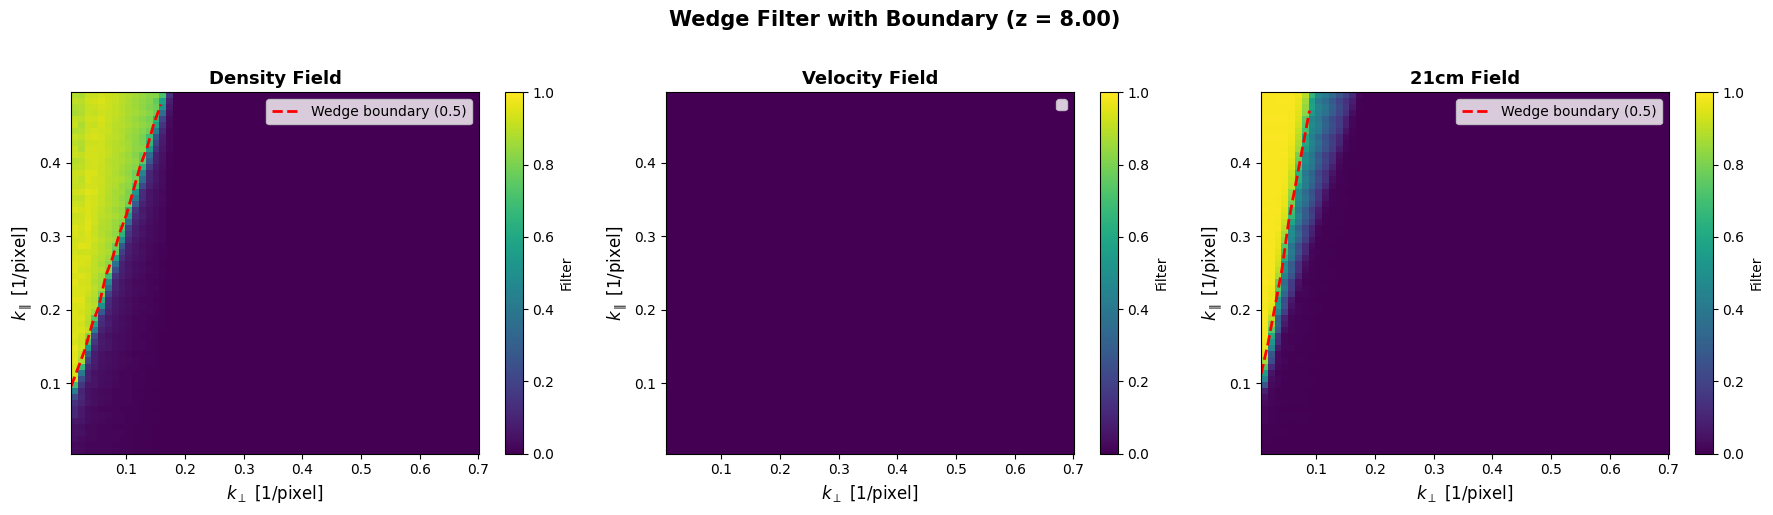

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Density
ax = axes[0]
im = ax.imshow(filter_den_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap='viridis', vmin=0, vmax=1)
if len(kp_wedge_den) > 0:
    ax.plot(kp_wedge_den, kpar_wedge_den, 'r--', linewidth=2, label=f'Wedge boundary ({threshold:.1f})')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title('Density Field', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Filter')

# Plot 2: Velocity
ax = axes[1]
im = ax.imshow(filter_vz_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap='viridis', vmin=0, vmax=1)
if len(kp_wedge_vz) > 0:
    ax.plot(kp_wedge_vz, kpar_wedge_vz, 'r--', linewidth=2, label=f'Wedge boundary ({threshold:.1f})')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title('Velocity Field', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Filter')

# Plot 3: 21cm
ax = axes[2]
im = ax.imshow(filter_t21_2d.T, origin='lower', aspect='auto',
               extent=[k_perp_bins[0], k_perp_bins[-1], k_par_bins[0], k_par_bins[-1]],
               cmap='viridis', vmin=0, vmax=1)
if len(kp_wedge_t21) > 0:
    ax.plot(kp_wedge_t21, kpar_wedge_t21, 'r--', linewidth=2, label=f'Wedge boundary ({threshold:.1f})')
ax.set_xlabel(r'$k_\perp$ [1/pixel]', fontsize=12)
ax.set_ylabel(r'$k_\parallel$ [1/pixel]', fontsize=12)
ax.set_title('21cm Field', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Filter')

plt.suptitle(f'Wedge Filter with Boundary (z = {actual_z:.2f})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/wedge_filter_with_boundary.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:

def compute_1d_power_spectrum(field_3d, box_size_mpc=300.0):
    """
    Compute spherically averaged 1D power spectrum.
    """
    # Compute power spectrum
    power, k_bins = get_power(
        field_3d,
        boxlength=box_size_mpc,
        return_summed=False
    )
    
    return k_bins, power

print("\nComputing 1D power spectra...")

# Density
k_den, P_den_unfiltered = compute_1d_power_spectrum(den_chunk)
_, P_den_filtered = compute_1d_power_spectrum(den_filtered)

# Velocity
k_vz, P_vz_unfiltered = compute_1d_power_spectrum(vz_chunk)
_, P_vz_filtered = compute_1d_power_spectrum(vz_filtered)

# 21cm
k_t21, P_t21_unfiltered = compute_1d_power_spectrum(t21_unfiltered)
_, P_t21_filtered = compute_1d_power_spectrum(t21_filtered)

print("1D power spectra computed!")

# ============================================================================
# CELL 13: Plot 1D Power Spectra Comparison
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Density
ax = axes[0]
ax.loglog(k_den, P_den_unfiltered, 'b-', linewidth=2, label='Unfiltered', alpha=0.7)
ax.loglog(k_den, P_den_filtered, 'r-', linewidth=2, label='Wedge filtered', alpha=0.7)
ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=12)
ax.set_ylabel(r'$P(k)$ [Mpc/h]$^3$', fontsize=12)
ax.set_title('Density Power Spectrum', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Velocity
ax = axes[1]
ax.loglog(k_vz, P_vz_unfiltered, 'b-', linewidth=2, label='Unfiltered', alpha=0.7)
ax.loglog(k_vz, P_vz_filtered, 'r-', linewidth=2, label='Wedge filtered', alpha=0.7)
ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=12)
ax.set_ylabel(r'$P(k)$ [(km/s)$^2$ (Mpc/h)$^3$]', fontsize=12)
ax.set_title('Velocity Power Spectrum', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: 21cm
ax = axes[2]
ax.loglog(k_t21, P_t21_unfiltered, 'b-', linewidth=2, label='Unfiltered', alpha=0.7)
ax.loglog(k_t21, P_t21_filtered, 'r-', linewidth=2, label='Wedge filtered', alpha=0.7)
ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=12)
ax.set_ylabel(r'$P(k)$ [mK$^2$ (Mpc/h)$^3$]', fontsize=12)
ax.set_title('21cm Power Spectrum', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('1D Power Spectra: Before vs After Wedge Filtering', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/power_spectra_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


Computing 1D power spectra...


TypeError: get_power() got an unexpected keyword argument 'return_summed'

In [ ]:

print("\n" + "="*80)
print("POWER LOSS STATISTICS")
print("="*80)

# Compute fractional power loss
power_loss_den = 1 - P_den_filtered / P_den_unfiltered
power_loss_vz = 1 - P_vz_filtered / P_vz_unfiltered
power_loss_t21 = 1 - P_t21_filtered / P_t21_unfiltered

print(f"\nDensity field:")
print(f"  Mean power loss: {np.mean(power_loss_den):.2%}")
print(f"  Max power loss: {np.max(power_loss_den):.2%}")

print(f"\nVelocity field:")
print(f"  Mean power loss: {np.mean(power_loss_vz):.2%}")
print(f"  Max power loss: {np.max(power_loss_vz):.2%}")

print(f"\n21cm field:")
print(f"  Mean power loss: {np.mean(power_loss_t21):.2%}")
print(f"  Max power loss: {np.max(power_loss_t21):.2%}")

# ============================================================================
# CELL 15: Summary Plot - Power Loss vs k
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.semilogx(k_den, power_loss_den, 'b-', linewidth=2, label='Density', alpha=0.7)
ax.semilogx(k_vz, power_loss_vz, 'r-', linewidth=2, label='Velocity', alpha=0.7)
ax.semilogx(k_t21, power_loss_t21, 'g-', linewidth=2, label='21cm', alpha=0.7)

ax.set_xlabel(r'$k$ [h/Mpc]', fontsize=13)
ax.set_ylabel('Fractional Power Loss', fontsize=13)
ax.set_title(f'Power Loss Due to Wedge Filtering (z = {actual_z:.2f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('plots/power_loss_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated plots:")
print("  - plots/wedge_filter_kspace.png")
print("  - plots/wedge_filter_with_boundary.png")
print("  - plots/power_spectra_comparison.png")
print("  - plots/power_loss_vs_k.png")



Computing 3D Fourier transforms...
FFT computation complete!

k_perp range: [0.0000, 0.7071]
k_parallel range: [0.0000, 0.5000]

Filter transfer functions computed!
Density filter - mean: 0.0149, min: 0.0000
Velocity filter - mean: 0.0000, min: 0.0000
21cm filter - mean: 0.0146, min: 0.0000
